<a href="https://colab.research.google.com/github/kbsha/AIMS-RIC-Hackaton-Project1-Deployed-on_streamlite/blob/main/AIMSRICDatasetgenerationand_ModelTrainigSample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

# ----------------------------
# PRODUCT CONFIG
# ----------------------------
products = {
    "tomato": {"SL": 72, "cost_range": (300, 500), "Q0": 1000, "alpha": 1.2},
    "milk": {"SL": 24, "cost_range": (800, 1200), "Q0": 800, "alpha": 1.5},
    "tilapia": {"SL": 18, "cost_range": (1500, 2500), "Q0": 600, "alpha": 1.3},
    "banana": {"SL": 120, "cost_range": (200, 400), "Q0": 1200, "alpha": 1.0},
}

days = 7
hours_per_day = 24

data = []

# ----------------------------
# GENERATION LOOP
# ----------------------------
for product, cfg in products.items():
    SL = cfg["SL"]
    Q0 = cfg["Q0"]
    alpha = cfg["alpha"]

    base_cost = np.random.uniform(*cfg["cost_range"])

    for day in range(days):
        for hour in range(hours_per_day):

            # ----------------------------
            # Price dynamics
            # ----------------------------
            morning_premium = 1.10 if 6 <= hour <= 10 else 1.0
            competitor_mean = base_cost * np.random.uniform(0.9, 1.1)

            competitor_price = competitor_mean * np.random.uniform(0.85, 1.15)
            our_price = competitor_price * np.random.uniform(0.95, 1.05) * morning_premium

            # ----------------------------
            # Freshness decay
            # ----------------------------
            age = np.random.uniform(0, SL)
            freshness_factor = max(0, 1 - (age / SL) ** 1.5)

            # ----------------------------
            # Reference price
            # ----------------------------
            p_ref = competitor_mean

            # ----------------------------
            # Demand model
            # ----------------------------
            demand = Q0 * np.exp(-alpha * (our_price - p_ref) / p_ref) * freshness_factor

            # ----------------------------
            # Store record
            # ----------------------------
            data.append({
                "product": product,
                "day": day,
                "hour": hour,
                "age_hours": age,
                "SL": SL,
                "base_cost": base_cost,
                "competitor_price": competitor_price,
                "our_price": our_price,
                "freshness_factor": freshness_factor,
                "demand": max(0, demand)
            })

df = pd.DataFrame(data)

print(df.head())

# Save dataset
df.to_csv("synthetic_perishable_market.csv", index=False)
print("\nDataset saved: synthetic_perishable_market.csv")

  product  day  hour  age_hours  SL   base_cost  competitor_price   our_price  \
0  tomato    0     0  11.233342  72  374.908024        437.148313  441.461152   
1  tomato    0     1  43.280281  72  374.908024        302.830189  313.919109   
2  tomato    0     2  59.935870  72  374.908024        334.344727  350.055915   
3  tomato    0     3  21.905441  72  374.908024        319.611678  309.492917   
4  tomato    0     4  44.053408  72  374.908024        369.072095  361.366945   

   freshness_factor      demand  
0          0.938374  852.324792  
1          0.533946  602.609096  
2          0.240494  272.327053  
3          0.832186  965.806556  
4          0.521402  547.609746  

Dataset saved: synthetic_perishable_market.csv


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

# ----------------------------
# CONFIG
# ----------------------------
products = {
    "tomato": {"SL": 72, "cost": (300, 500), "Q0": 100, "alpha": 1.4},
    "milk": {"SL": 24, "cost": (800, 1200), "Q0": 80, "alpha": 1.8},
    "tilapia": {"SL": 18, "cost": (1500, 2500), "Q0": 60, "alpha": 1.6},
    "banana": {"SL": 120, "cost": (200, 400), "Q0": 120, "alpha": 1.1},
}

start_time = datetime(2026, 1, 1, 0, 0)

# ----------------------------
# 1. STOCK DATA
# ----------------------------
stock_rows = []

for i in range(120):
    product = np.random.choice(list(products.keys()))
    cfg = products[product]

    stock_rows.append({
        "sku_id": f"SKU{i:04d}",
        "product": product,
        "purchased_at": start_time + timedelta(hours=np.random.randint(0, 72)),
        "quantity": np.random.randint(5, 50),
        "unit_cost_xaf": np.random.uniform(*cfg["cost"]),
        "shelf_life_hours": cfg["SL"],
        "supplier": f"supplier_{np.random.randint(1,6)}"
    })

stock_df = pd.DataFrame(stock_rows)
stock_df.to_csv("stock.csv", index=False)

# ----------------------------
# 2. COMPETITOR PRICES (48h × 12 stalls × products)
# ----------------------------
comp_rows = []

stalls = [f"stall_{i}" for i in range(12)]

for h in range(48):
    timestamp = start_time + timedelta(hours=h)

    for stall in stalls:
        for product in products:
            base = np.random.uniform(800, 3000)

            # morning premium
            premium = 1.1 if 6 <= timestamp.hour <= 10 else 1.0

            price = base * np.random.uniform(0.85, 1.15) * premium

            comp_rows.append({
                "timestamp": timestamp,
                "stall": stall,
                "product": product,
                "price": price
            })

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv("competitor_prices.csv", index=False)

# ----------------------------
# 3. SALES HISTORY (demand simulation)
# ----------------------------
sales_rows = []

for i in range(2000):
    product = np.random.choice(list(products.keys()))
    cfg = products[product]

    age = np.random.uniform(0, cfg["SL"])
    SL = cfg["SL"]

    freshness = max(0, 1 - (age / SL) ** 1.5)

    p_ref = np.random.uniform(1000, 2000)
    price = p_ref * np.random.uniform(0.9, 1.3)

    demand = cfg["Q0"] * np.exp(-cfg["alpha"] * (price - p_ref) / p_ref) * freshness

    sales_rows.append({
        "timestamp": start_time + timedelta(minutes=np.random.randint(0, 2880)),
        "product": product,
        "price": price,
        "age_hours": age,
        "demand_proxy": max(0, demand)
    })

sales_df = pd.DataFrame(sales_rows)
sales_df.to_csv("sales_history.csv", index=False)

print("✅ All datasets generated:")
print(" - stock.csv")
print(" - competitor_prices.csv")
print(" - sales_history.csv")

✅ All datasets generated:
 - stock.csv
 - competitor_prices.csv
 - sales_history.csv


In [5]:
import pandas as pd

stock = pd.read_csv("stock.csv")
competitor = pd.read_csv("competitor_prices.csv")
sales = pd.read_csv("sales_history.csv")

print(stock.head())
print(sales.head())

    sku_id  product         purchased_at  quantity  unit_cost_xaf  \
0  SKU0000  tilapia  2026-01-03 03:00:00        33    1683.434790   
1  SKU0001   tomato  2026-01-01 23:00:00         7     304.116899   
2  SKU0002   banana  2026-01-02 05:00:00        42     200.155753   
3  SKU0003   tomato  2026-01-02 08:00:00        16     422.330632   
4  SKU0004   banana  2026-01-03 00:00:00        31     322.370579   

   shelf_life_hours    supplier  
0                18  supplier_5  
1                72  supplier_2  
2               120  supplier_4  
3                72  supplier_5  
4               120  supplier_2  
             timestamp product        price   age_hours  demand_proxy
0  2026-01-01 07:34:00  banana  1642.353855   50.994422     70.578379
1  2026-01-02 13:56:00  banana  1176.118464  113.253373     10.654352
2  2026-01-01 06:41:00    milk  1932.400163   14.801105     38.494426
3  2026-01-01 05:08:00    milk  2027.869120    8.404768     40.154369
4  2026-01-01 19:44:00    milk 

In [6]:
import numpy as np

sales["product_encoded"] = sales["product"].astype("category").cat.codes

# competitor aggregation (simplified)
comp_avg = competitor.groupby("product")["price"].mean().reset_index()
comp_avg.columns = ["product", "comp_avg_price"]

df = sales.merge(comp_avg, on="product", how="left")

X = df[["price", "age_hours", "comp_avg_price", "product_encoded"]]
y = df["demand_proxy"]

print(X.head())

         price   age_hours  comp_avg_price  product_encoded
0  1642.353855   50.994422     1867.298404                0
1  1176.118464  113.253373     1867.298404                0
2  1932.400163   14.801105     1991.603751                1
3  2027.869120    8.404768     1991.603751                1
4  2486.444475    9.701799     1991.603751                1


In [7]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9155377431740147


In [8]:
def optimize_price(product_encoded, age, comp_price):

    best_price = 0
    best_value = -1

    for price in np.linspace(500, 5000, 50):

        X_input = pd.DataFrame([[
            price,
            age,
            comp_price,
            product_encoded
        ]], columns=["price","age_hours","comp_avg_price","product_encoded"])

        demand = model.predict(X_input)[0]
        profit = (price * demand)

        if profit > best_value:
            best_value = profit
            best_price = price

    return best_price, best_value

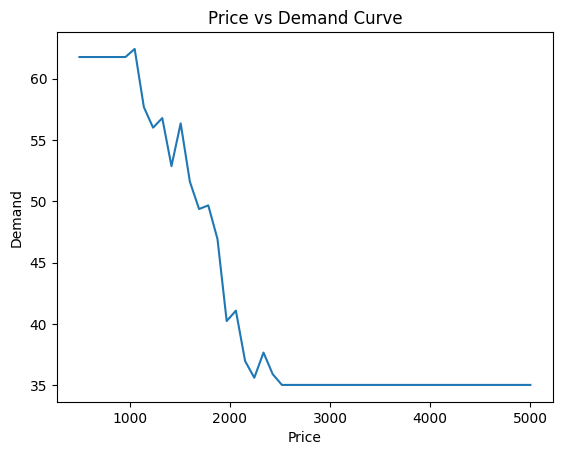

In [9]:
import matplotlib.pyplot as plt

prices = np.linspace(500, 5000, 50)
demands = []

for p in prices:
    X_input = pd.DataFrame([[p, 10, 2000, 0]],
        columns=["price","age_hours","comp_avg_price","product_encoded"]
    )
    demands.append(model.predict(X_input)[0])

plt.plot(prices, demands)
plt.title("Price vs Demand Curve")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.show()

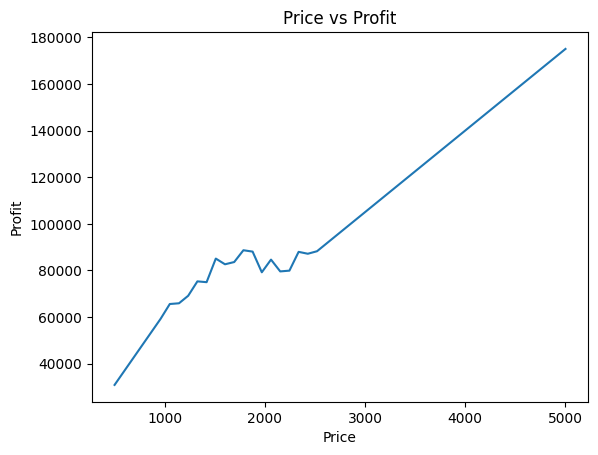

In [10]:
profits = [p * d for p, d in zip(prices, demands)]

plt.plot(prices, profits)
plt.title("Price vs Profit")
plt.xlabel("Price")
plt.ylabel("Profit")
plt.show()

In [12]:
import pandas as pd

results = X_test.copy()
results["actual_demand"] = y_test.values
results["predicted_demand"] = model.predict(X_test)

results.head(20)

,price,age_hours,comp_avg_price,product_encoded,actual_demand,predicted_demand
1752,1248.786573,10.196830,1991.603751,1,61.176955,58.808937
1098,1982.963815,8.829755,1867.298404,0,92.610799,96.746841
1826,1238.000407,44.013997,1947.593541,3,48.643842,54.384861
1794,1932.689922,20.471017,1947.593541,3,71.006600,70.387810
1327,1952.275417,11.422241,1991.603751,1,53.836197,36.502827
951,1901.263754,61.586397,1867.298404,0,74.590968,66.503433
743,2295.546897,8.416601,1922.361625,2,28.506583,29.178967
1304,1830.326501,0.709972,1947.593541,3,87.968685,98.070969
33,1675.438060,15.953741,1991.603751,1,26.480568,30.837997
1122,2051.453287,11.454709,1922.361625,2,22.455179,23.423130


In [13]:
results["error"] = abs(results["actual_demand"] - results["predicted_demand"])

results_sorted = results.sort_values("error", ascending=False)

results_sorted.head(10)

,price,age_hours,comp_avg_price,product_encoded,actual_demand,predicted_demand,error
909,1638.608804,3.341973,1867.298404,0,132.190404,98.875107,33.315297
1016,1742.895022,1.201549,1991.603751,1,89.690261,65.710732,23.979530
1453,1323.745181,1.786272,1947.593541,3,105.846239,82.268555,23.577684
53,1874.886656,6.688664,1991.603751,1,73.703906,51.381218,22.322688
314,1680.321148,5.733764,1867.298404,0,90.930969,112.551331,21.620361
168,1748.770912,5.116894,1991.603751,1,74.566301,53.501419,21.064881
216,1597.086067,10.755478,1947.593541,3,98.412139,77.657013,20.755126
1879,1339.837005,3.727512,1991.603751,1,44.087618,64.842308,20.754691
546,1486.632082,9.666853,1991.603751,1,66.857964,46.521408,20.336556
1869,1680.301489,35.079542,1867.298404,0,82.640948,102.614906,19.973958


In [14]:
def linear_demand(price, a=100, b=0.05):
    return max(0, a - b * price)

In [15]:
import numpy as np

def sigmoid_demand(price, Qmax=100, k=0.01, p0=2000):
    return Qmax / (1 + np.exp(k * (price - p0)))

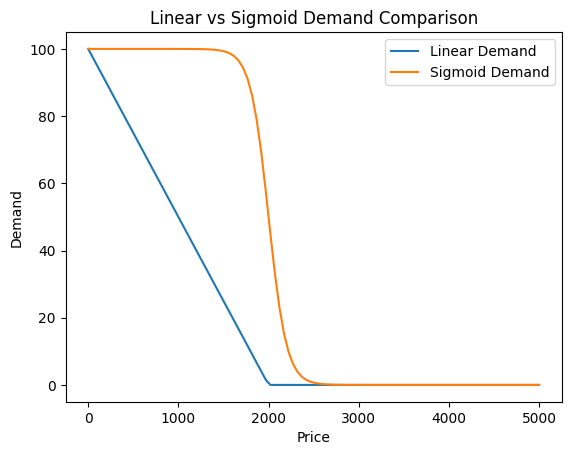

In [16]:
import matplotlib.pyplot as plt
import numpy as np

prices = np.linspace(0, 5000, 100)

linear = [linear_demand(p) for p in prices]
sigmoid = [sigmoid_demand(p) for p in prices]

plt.plot(prices, linear, label="Linear Demand")
plt.plot(prices, sigmoid, label="Sigmoid Demand")

plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Linear vs Sigmoid Demand Comparison")
plt.legend()
plt.show()

In [18]:
import joblib

joblib.dump(model, "demand_model.pkl")

['demand_model.pkl']